In [1]:
from config import (
    PORTFOLIO_FILE,
    RISK_PROFILE_FILE,
    MACRO_ANALYSIS_FILE,
    OUTPUT_FILE,
)
from src import (
    read_file,
    write_file,
    summarize_portfolio_results,
    summarize_risk_profile,
    summarize_macroeconomic_outlook,
    generate_investment_letter,
)

In [2]:
# Passo 1: Ler os arquivos de entrada
print("\n[1/4] Lendo arquivos de entrada...")
portfolio_data = read_file(PORTFOLIO_FILE)
print(f"  ✓ Portfólio lido: {PORTFOLIO_FILE.name}")

risk_profile_data = read_file(RISK_PROFILE_FILE)
print(f"  ✓ Perfil de risco lido: {RISK_PROFILE_FILE.name}")

macro_data = read_file(MACRO_ANALYSIS_FILE)
print(f"  ✓ Análise macro lida: {MACRO_ANALYSIS_FILE.name}")



[1/4] Lendo arquivos de entrada...
  ✓ Portfólio lido: XP - Albert_s portfolio.txt
  ✓ Perfil de risco lido: XP - Albert_s risk profile.txt
  ✓ Análise macro lida: XP - Macro analysis.txt


In [3]:
# Step 2: Resumir os dados
from src.portfolio_parser import summarize_portfolio, format_portfolio_summary, plot_allocation_donut

# Processa o arquivo de portfólio
resumo = summarize_portfolio(PORTFOLIO_FILE)

# Exibe o resumo formatado
resumo_formatado  = format_portfolio_summary(resumo)
print(resumo_formatado)

PORTFOLIO SUMMARY

Client Name: Albert da Silva
Investment Advisor: Antonio Bicudo (A7699)
  Position: Assessor de Investimentos
  Company: XP
Total Assets: R$ 386,858.82
Total Invested: R$ 312,186.20
Available Balance: R$ 74,672.62

--------------------------------------------------------------------------------
STOCKS - 19.32% of portfolio
--------------------------------------------------------------------------------

Code: LREN3
  Position: R$ 27,812.04
  % Allocation: 8.91%
  Return Rate: -41.70%
  Last Price: R$ 16.94
  Average Price: R$ 29.05
  Quantity: 1642
  Investment Date: 22/04/2021

Code: MRFG3
  Position: R$ 15,432.89
  % Allocation: 4.94%
  Return Rate: 43.50%
  Last Price: R$ 10.26
  Average Price: R$ 7.15
  Quantity: 1504
  Investment Date: 22/04/2021

Code: ARZZ3
  Position: R$ 10,923.72
  % Allocation: 3.50%
  Return Rate: -31.05%
  Last Price: R$ 56.58
  Average Price: R$ 82.06
  Quantity: 193
  Investment Date: 02/11/2022

Code: HAPV3
  Position: R$ 6,143.14
  % 

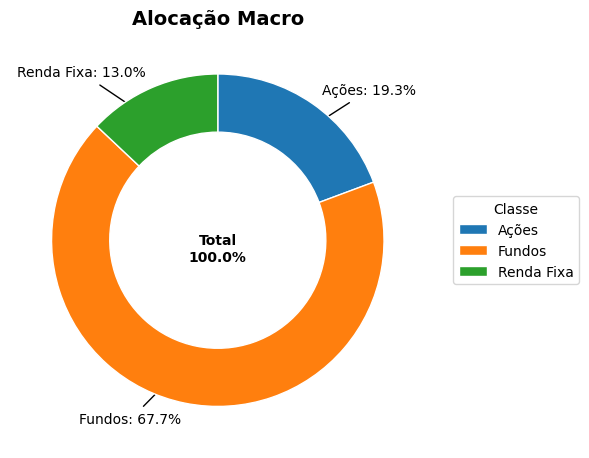

(<Figure size 600x600 with 1 Axes>, <Axes: title={'center': 'Alocação Macro'}>)

In [4]:
# Extra: Gerar gráfico macro alocação

plot_allocation_donut(
    resumo.stocks_percentage,
    resumo.funds_percentage,
    resumo.fixed_income_percentage)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

def plot_allocation_donut(
    stocks_pct, funds_pct, fixed_income_pct,
    total_invested=None,     # <----- NOVO
    labels=None,
    colors=None,
    title="Alocação Macro",
    figsize=(7,7),
    savepath=None
):
    """
    Gráfico de rosca profissional para alocação macro, permitindo incluir
    o valor total investido no centro do gráfico.
    """

    # Normaliza (aceita número ou array-like com 1 valor)
    def _to_number(x):
        if hasattr(x, "__len__") and not isinstance(x, (str, bytes)):
            return float(np.asarray(x).ravel()[0])
        return float(x)

    s = _to_number(stocks_pct)
    f = _to_number(funds_pct)
    r = _to_number(fixed_income_pct)

    vals = np.array([s, f, r], float)

    # Converte para % se necessário
    if vals.max() <= 1:
        vals *= 100

    if labels is None:
        labels = ["Ações", "Fundos", "Renda Fixa"]

    # Paleta executiva padrão
    if colors is None:
        colors = ["#4A90E2", "#F5A623", "#7ED321"]

    fig, ax = plt.subplots(figsize=figsize)

    wedges, _ = ax.pie(
        vals,
        colors=colors,
        startangle=90,
        counterclock=False,
        labels=None,
        wedgeprops=dict(width=0.33, edgecolor="white", linewidth=1.5)
    )

    # Círculo central (fundo claro premium)
    centre_circle = Circle((0, 0), 0.70, fc="white", ec="none")
    ax.add_artist(centre_circle)

    # ---------------------------
    # TEXTO CENTRAL (NOVO)
    # ---------------------------

    if total_invested is not None:
        # Formata como moeda
        formatted = f"R$ {total_invested:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
        
        ax.text(
            0, 0.08,
            formatted,
            ha="center", va="center",
            fontsize=18, fontweight="bold",
            color="#333333"
        )
        
        ax.text(
            0, -0.07,
            "Total Investido",
            ha="center", va="center",
            fontsize=11, color="#666666"
        )
    else:
        # fallback – mostra apenas porcentagem total
        ax.text(
            0, 0.02,
            "100%",
            ha="center", va="center",
            fontsize=22, fontweight="bold",
            color="#333333"
        )

        ax.text(
            0, -0.12,
            "Total",
            ha="center", va="center",
            fontsize=11, color="#666666"
        )

    # ---------------------------
    # RÓTULOS EXTERNOS
    # ---------------------------

    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1)/2 + p.theta1
        x = np.cos(np.deg2rad(ang))
        y = np.sin(np.deg2rad(ang))

        ax.annotate(
            f"{labels[i]}\n{vals[i]:.1f}%",
            xy=(x*0.78, y*0.78),
            xytext=(x*1.20, y*1.20),
            ha="center",
            fontsize=11,
            bbox=dict(
                boxstyle="round,pad=0.3",
                fc="white",
                ec="#E0E0E0",
                alpha=0.9
            ),
            arrowprops=dict(
                arrowstyle="-",
                lw=1.0,
                color="#888888"
            )
        )

    ax.set_title(
        title,
        fontsize=16,
        fontweight="semibold",
        color="#222222",
        pad=20
    )

    ax.set_aspect("equal")
    plt.tight_layout()

    if savepath:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

    return fig, ax


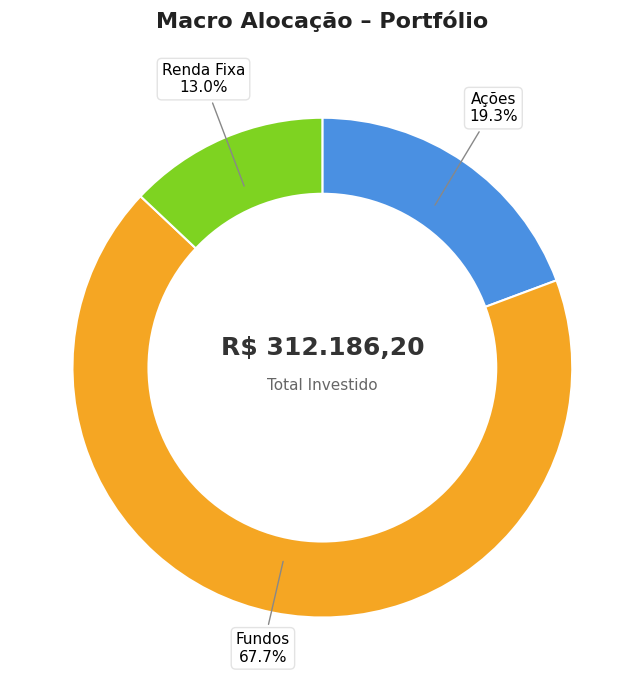

(<Figure size 700x700 with 1 Axes>,
 <Axes: title={'center': 'Macro Alocação – Portfólio'}>)

In [10]:
plot_allocation_donut(
    resumo.stocks_percentage,
    resumo.funds_percentage,
    resumo.fixed_income_percentage,
    total_invested=resumo.total_invested,
    title="Macro Alocação – Portfólio"
)

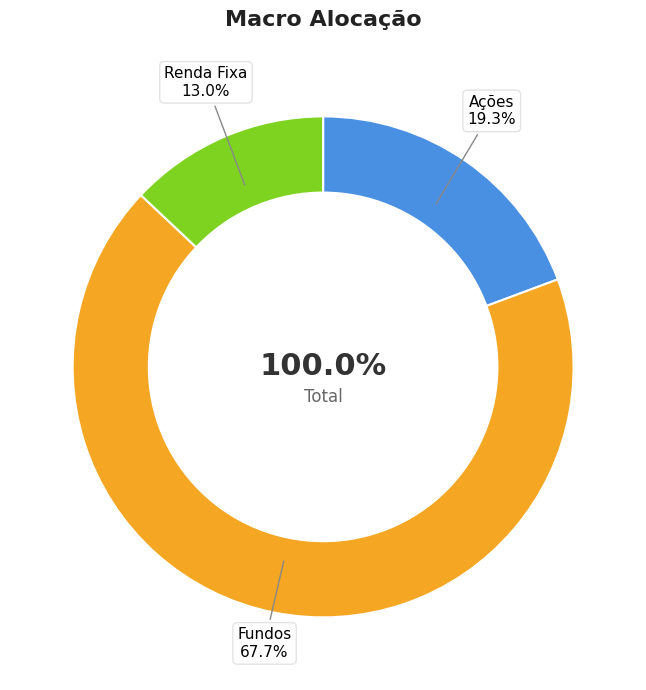

(<Figure size 700x700 with 1 Axes>, <Axes: title={'center': 'Macro Alocação'}>)

In [6]:
plot_allocation_donut(
    resumo.stocks_percentage,
    resumo.funds_percentage,
    resumo.fixed_income_percentage,
    title="Macro Alocação"
)

In [11]:
import numpy as np
import matplotlib.pyplot as plt

def plot_donut_with_subassets(
    summary,
    title="Alocação do Portfólio",
    figsize=(8,8),
    threshold_small=0.03,  # abaixo disso vira "fatia fina"
    show_values_center=True
):
    """
    Gera um donut duplo:
      - Rosca externa: classes (Ações / Fundos / Renda Fixa)
      - Rosca interna: ativos dentro de cada classe
      - Ativos pequenos viram fatias finas (Opção C)
    """

    # ----- Classes principais -----
    class_labels = ["Ações", "Fundos", "Renda Fixa"]
    class_values = [
        summary.stocks_percentage,
        summary.funds_percentage,
        summary.fixed_income_percentage
    ]
    class_colors = ["#4A90E2", "#F5A623", "#7ED321"]

    fig, ax = plt.subplots(figsize=figsize)

    # Rosca externa (classes)
    wedges, _ = ax.pie(
        class_values,
        labels=None,
        startangle=90,
        counterclock=False,
        colors=class_colors,
        radius=1.0,
        wedgeprops=dict(width=0.28, edgecolor="white", linewidth=1.5)
    )

    # ----- Criar lista de ativos por classe -----
    class_assets = [
        summary.stocks,
        summary.funds,
        summary.fixed_income_securities
    ]

    # ----- Rosca interna (ativos dentro de cada classe) -----
    start_angle = 90

    for i, (cl_value, assets, cl_color) in enumerate(zip(class_values, class_assets, class_colors)):
        if cl_value <= 0:
            continue

        # ângulo total da classe
        angle_span = (cl_value / sum(class_values)) * 360

        # criar percentuais relativos à classe
        pct_assets = []
        for a in assets:
            pct_total = a.allocation_percentage
            if cl_value > 0:
                pct_rel = pct_total / cl_value
                pct_assets.append((a, pct_rel))

        # normalizar (caso arredondamentos causem diferença)
        total_rel = sum([p for _, p in pct_assets])
        pct_assets = [(a, p / total_rel) for a, p in pct_assets]

        # desenhar cada ativo como fatia radial interna
        angle_pointer = start_angle

        for a, pct_rel in pct_assets:
            asset_angle = pct_rel * angle_span

            # decidir estilo
            if pct_rel < threshold_small:
                width = 0.10      # muito fino → premium
                lw = 0.5
                alpha = 0.6
            else:
                width = 0.22
                lw = 1.0
                alpha = 1.0

            ax.pie(
                [asset_angle],
                radius=0.72,
                startangle=angle_pointer,
                counterclock=False,
                colors=[cl_color],
                wedgeprops=dict(
                    width=width,
                    edgecolor="white",
                    linewidth=lw,
                    alpha=alpha
                )
            )

            # rótulos apenas para ativos maiores
            if pct_rel >= threshold_small:
                mid_angle = angle_pointer - asset_angle / 2
                x = np.cos(np.deg2rad(mid_angle)) * 0.45
                y = np.sin(np.deg2rad(mid_angle)) * 0.45
                ax.text(
                    x, y,
                    f"{a.name if hasattr(a, 'name') else a.code}\n{pct_rel*100:.1f}%",
                    ha="center", va="center",
                    fontsize=8
                )

            angle_pointer -= asset_angle

        start_angle -= angle_span

    # ----- Centro com valor total -----
    if show_values_center:
        ax.text(
            0, 0.05,
            f"R$ {summary.total_invested:,.2f}".replace(",", "X").replace(".", ",").replace("X", "."),
            ha="center", va="center",
            fontsize=18, fontweight="bold", color="#333"
        )
        ax.text(
            0, -0.08,
            "Total Investido",
            ha="center", va="center",
            fontsize=11, color="#666"
        )

    ax.set(aspect="equal")
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    plt.tight_layout()
    plt.show()


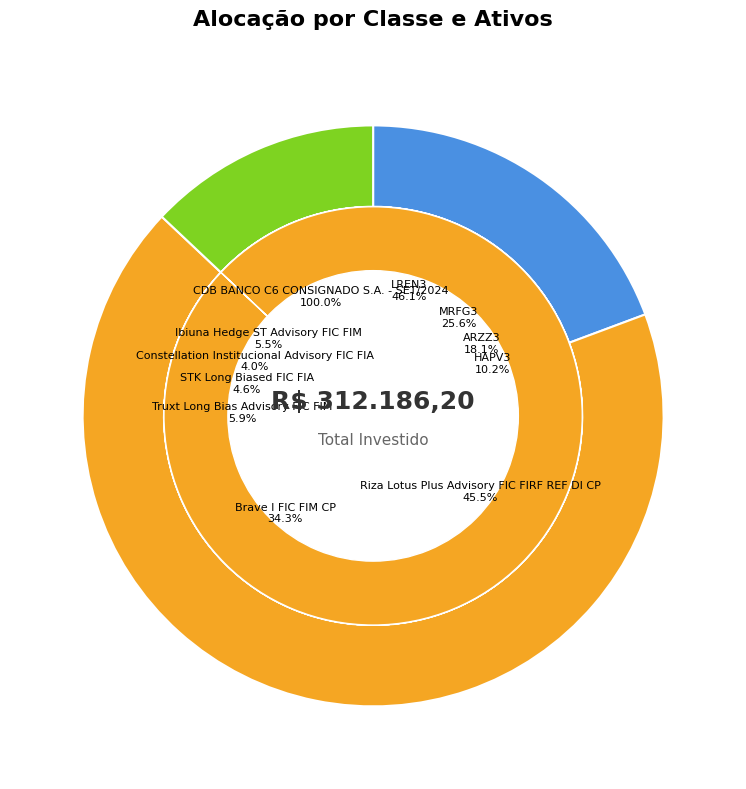

In [12]:
plot_donut_with_subassets(resumo, title="Alocação por Classe e Ativos")


In [16]:
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import numpy as np

from src.portfolio_parser import PortfolioSummary

def plot_portfolio_donut_with_inner_ring(summary: PortfolioSummary,
                                         min_asset_pct_within_class=0.03,
                                         title="Distribuição do Portfólio"):
    """
    Cria:
    - Aro principal (Ações, Fundos, Renda Fixa)
    - Anel interno fino dentro de cada fatia, com os ativos daquela classe
      proporcionais dentro da classe.
    """

    # =============================
    # 1) Dados principais
    # =============================
    class_labels = ["Ações", "Fundos", "Renda Fixa"]
    class_values = [
        summary.stocks_percentage,
        summary.funds_percentage,
        summary.fixed_income_percentage
    ]

    class_colors = {
        "Ações": "#2E86C1",
        "Fundos": "#AF7AC5",
        "Renda Fixa": "#F5B041",
    }

    outer_colors = [class_colors[c] for c in class_labels]

    # =============================
    # 2) Dados das subfatias
    # =============================

    def get_assets(items, class_pct):
        """Retorna lista de (nome, pct_normalizado) filtrados."""
        assets = []
        for item in items:
            if class_pct > 0:
                pct = item.allocation_percentage / class_pct
            else:
                pct = 0
            if pct >= min_asset_pct_within_class:
                assets.append((getattr(item, "code", getattr(item, "name", "Ativo")), pct))

        if len(assets) == 0:
            return []

        # Normaliza para somar 1
        total = sum(x[1] for x in assets)
        return [(name, pct / total) for name, pct in assets]

    stocks = get_assets(summary.stocks, summary.stocks_percentage)
    funds = get_assets(summary.funds, summary.funds_percentage)
    fixed_income = get_assets(summary.fixed_income_securities, summary.fixed_income_percentage)

    inner_assets_list = [stocks, funds, fixed_income]

    # =============================
    # 3) Criar figura
    # =============================
    fig, ax = plt.subplots(figsize=(11, 11))
    ax.set_aspect("equal")

    # =============================
    # 4) Desenhar aro principal
    # =============================
    wedges, _ = ax.pie(
        class_values,
        labels=class_labels,
        colors=outer_colors,
        radius=1.0,
        wedgeprops=dict(width=0.30, edgecolor="white"),
        startangle=90,
        labeldistance=1.07,
        textprops={'fontsize': 13}
    )

    # =============================
    # 5) Desenhar anel interno fino
    # =============================
    for wedge, assets, class_name in zip(wedges, inner_assets_list, class_labels):

        if len(assets) == 0:
            continue

        # Ângulos da fatia principal
        theta1, theta2 = wedge.theta1, wedge.theta2
        total_angle = theta2 - theta1

        # Distribuição interna
        cumulative = np.cumsum([x[1] for x in assets])
        inner_angles = [theta1] + list(theta1 + cumulative * total_angle)

        for (label, pct), a1, a2 in zip(assets, inner_angles[:-1], inner_angles[1:]):
            # Desenha um wedge mais fino dentro da fatia
            inner_wedge = Wedge(
                center=(0, 0),
                r=0.70,              # raio externo do anel interno
                width=0.18,          # espessura do anel interno
                theta1=a1,
                theta2=a2,
                facecolor=class_colors[class_name],
                edgecolor="white",
                linewidth=0.8,
                alpha=0.55
            )
            ax.add_patch(inner_wedge)

    # =============================
    # 6) Título elegante
    # =============================
    plt.title(title, fontsize=20, fontweight="bold", pad=20)

    plt.show()



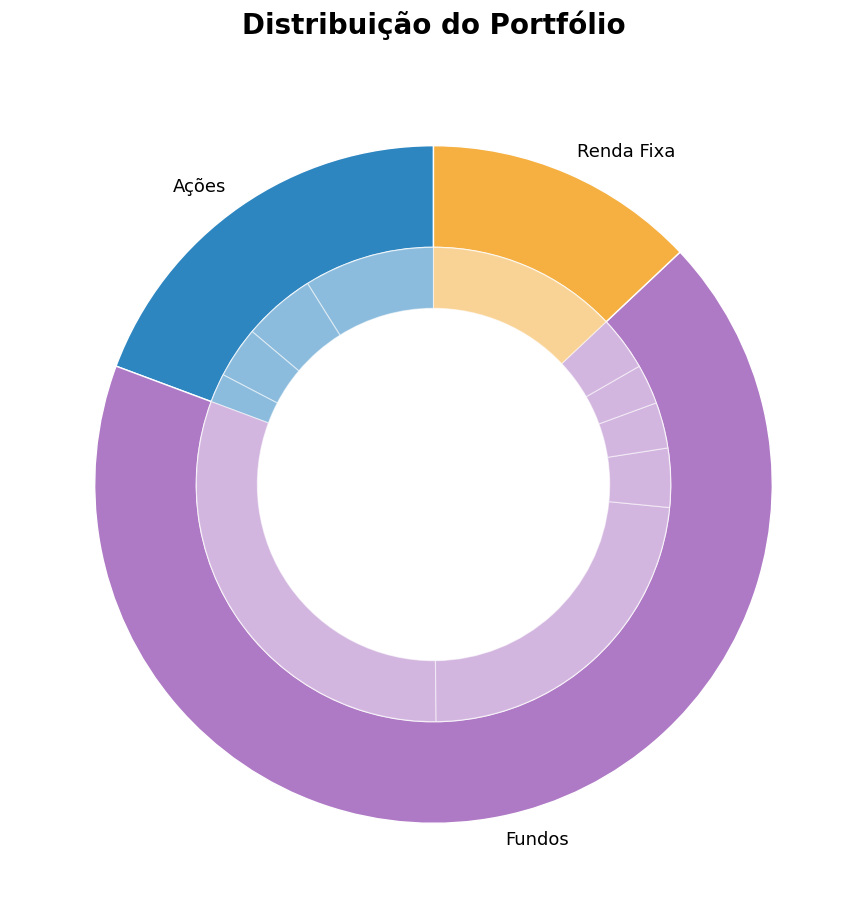

In [17]:
plot_portfolio_donut_with_inner_ring(resumo)


In [41]:
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import numpy as np
import textwrap

def plot_portfolio_donut_with_inner_ring(
    summary: PortfolioSummary,
    min_asset_pct_within_class=0.03,
    min_label_angle_deg=8,
    title="Distribuição do Portfólio"
):
    """
    Igual à sua função original, mas com ajuste automático de texto
    para que não ultrapasse o espaço da subfatia.
    """

    class_labels = ["Ações", "Fundos", "Renda Fixa"]
    class_values = [
        summary.stocks_percentage,
        summary.funds_percentage,
        summary.fixed_income_percentage,
    ]

    class_colors = {
        "Ações": "#2E86C1",
        "Fundos": "#AF7AC5",
        "Renda Fixa": "#F5B041",
    }

    outer_colors = [class_colors[c] for c in class_labels]

    # ========== Subfatias ==========
    def get_assets(items, class_pct):
        assets = []
        for item in items:
            if class_pct > 0:
                pct = item.allocation_percentage / class_pct
            else:
                pct = 0
            if pct >= min_asset_pct_within_class:
                name = getattr(item, "code", getattr(item, "name", "Ativo"))
                assets.append((name, pct))

        if not assets:
            return []

        total = sum(v for _, v in assets)
        return [(name, v / total) for name, v in assets]

    stocks = get_assets(summary.stocks, summary.stocks_percentage)
    funds = get_assets(summary.funds, summary.funds_percentage)
    fixed_income = get_assets(summary.fixed_income_securities, summary.fixed_income_percentage)

    inner_assets_list = [stocks, funds, fixed_income]

    fig, ax = plt.subplots(figsize=(11, 11))
    ax.set_aspect("equal")

    wedges, _ = ax.pie(
        class_values,
        labels=class_labels,
        colors=outer_colors,
        radius=1.0,
        wedgeprops=dict(width=0.30, edgecolor="white"),
        startangle=90,
        labeldistance=1.07,
        textprops={'fontsize': 13}
    )

    for wedge, pct in zip(wedges, class_values):
        theta1, theta2 = wedge.theta1, wedge.theta2
        angle_span = theta2 - theta1

        # só mostra se houver espaço
        if angle_span >= min_label_angle_deg:
            mid_angle = np.deg2rad((theta1 + theta2) / 2)
            text_r = 0.85  # posição radial dentro do aro principal (entre 1.0 e 0.70)

            pct_text = f"{pct*100:.1f}%"

            ax.text(
                text_r * np.cos(mid_angle),
                text_r * np.sin(mid_angle),
                pct_text,
                ha="center",
                va="center",
                fontsize=12,
                color="white",
                fontweight="bold"
            )

    # ========== Subfatias internas ==========
    for wedge, assets, class_name in zip(wedges, inner_assets_list, class_labels):

        if len(assets) == 0:
            continue

        theta1, theta2 = wedge.theta1, wedge.theta2
        total_angle = theta2 - theta1

        cumulative = np.cumsum([pct for _, pct in assets])
        inner_angles = [theta1] + list(theta1 + cumulative * total_angle)

        for (label, pct), a1, a2 in zip(assets, inner_angles[:-1], inner_angles[1:]):
            angle_span = a2 - a1

            inner_wedge = Wedge(
                center=(0, 0),
                r=0.70,
                width=0.18,
                theta1=a1,
                theta2=a2,
                facecolor=class_colors[class_name],
                edgecolor="white",
                linewidth=0.8,
                alpha=0.55,
            )
            ax.add_patch(inner_wedge)

            # ===============================================
            # 🔧 AJUSTE AUTOMÁTICO DO TEXTO
            # ===============================================
            if angle_span >= min_label_angle_deg:

                # posição radial do rótulo
                text_r = 0.61  
                mid_angle = np.deg2rad((a1 + a2) / 2)
                x = text_r * np.cos(mid_angle)
                y = text_r * np.sin(mid_angle)

                # --- 1. Limite máximo de caracteres baseado no ângulo ---
                # range de 0° a 40° → 0 a 12 caracteres
                max_chars = int( (angle_span / 40) * 12 )
                max_chars = max(max_chars, 5)       # nunca menos de 5
                max_chars = min(max_chars, 15)      # nunca mais de 15

                short_label = textwrap.fill(label[:max_chars], width=max_chars)

                # --- 2. Ajuste automático da fonte ---
                fontsize = 9
                if angle_span < 10:
                    fontsize = 7
                if angle_span < 7:
                    fontsize = 6

                # --- 3. Se ainda estiver muito longo, remover ---
                if len(short_label) > max_chars:
                    continue

                ax.text(
                    x, y,
                    short_label,
                    ha="center",
                    va="center",
                    fontsize=fontsize,
                    color="#222",
                    fontweight="bold"
                )

    # ========== Texto central ==========
    invested_text = f"Total Investido\nR$ {summary.total_invested:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")
    ax.text(0, 0, invested_text, ha="center", va="center", fontsize=15, fontweight="bold", color="#333")

    plt.title(title, fontsize=20, fontweight="bold", pad=20)
    plt.show()


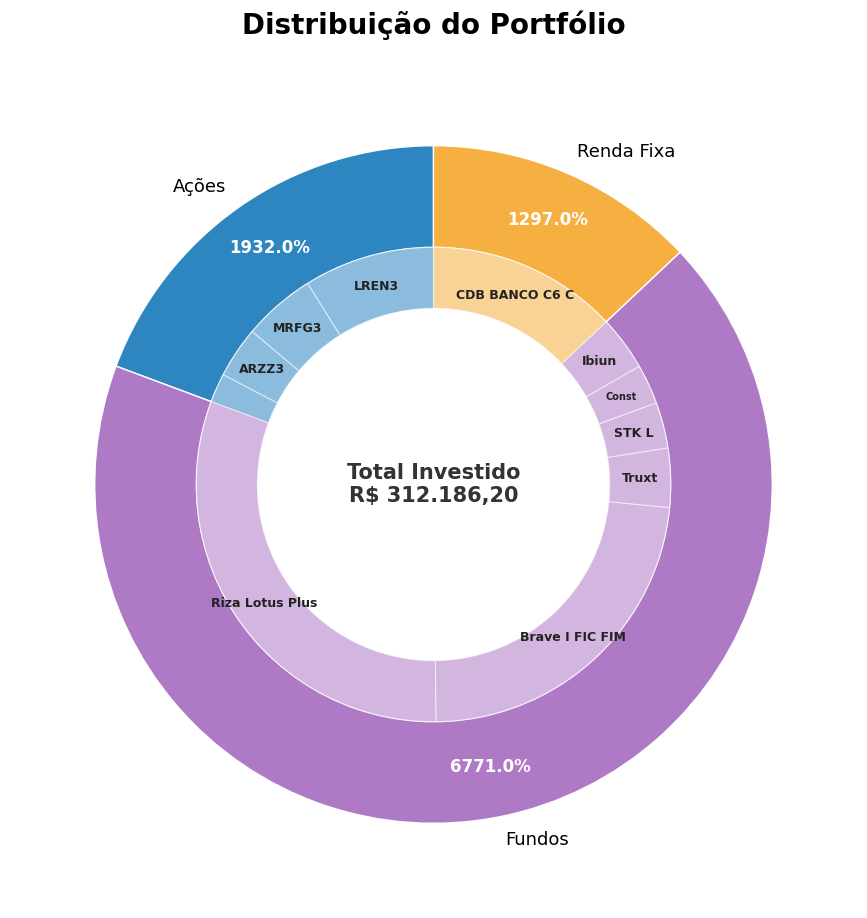

In [42]:
plot_portfolio_donut_with_inner_ring(resumo)

In [51]:
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import numpy as np

def plot_portfolio_donut_with_inner_ring(
    summary: PortfolioSummary,
    min_asset_pct_within_class=0.05,     # ativos menores que isso são omitidos
    min_label_angle_deg=8,               # ângulo mínimo para mostrar rótulo
    title="Distribuição do Portfólio",
    max_label_chars=12                   # limite para encurtar nomes de ativos
):
    """
    Gera:
    - Aro principal (Ações, Fundos, Renda Fixa)
    - Anel interno com subfatias proporcionais
    - Rótulos internos (se houver espaço)
    - Valor total investido no centro
    - Porcentagem de cada classe na borda externa
    """


    # =============================
    # Função para truncar labels
    # =============================
    def shorten_label(text: str, max_chars: int = max_label_chars) -> str:
        """Trunca um texto longo e adiciona '...'."""
        text = str(text)
        if len(text) <= max_chars:
            return text
        return text[:max_chars] + "..."


    # =============================
    # 1. Dados principais
    # =============================
    class_labels = ["Ações", "Fundos", "Renda Fixa"]
    raw_values = [
        summary.stocks_percentage,
        summary.funds_percentage,
        summary.fixed_income_percentage,
    ]

    # Conversão automática: valores entre 0–1 viram percentuais
    class_values = []
    class_pct_labels = []

    for v in raw_values:
        if v <= 1:          # assume proporção (0 a 1)
            pct = v * 100
        else:               # assume % direto (0 a 100)
            pct = v
        class_values.append(v)
        class_pct_labels.append(f"{pct:.1f}%")

    class_colors = {
        "Ações": "#2E86C1",
        "Fundos": "#AF7AC5",
        "Renda Fixa": "#F5B041",
    }

    outer_colors = [class_colors[c] for c in class_labels]

    # =============================
    # 2. Subfatias por classe
    # =============================
    def get_assets(items, class_pct):
        """Retorna lista de (nome, pct_normalizado)."""
        assets = []
        for item in items:
            if class_pct > 0:
                pct = item.allocation_percentage / class_pct
            else:
                pct = 0
            if pct >= min_asset_pct_within_class:
                name = getattr(item, "code", getattr(item, "name", "Ativo"))
                name = shorten_label(name)  # <<<<< aplica truncamento
                assets.append((name, pct))

        if not assets:
            return []

        total = sum(v for _, v in assets)
        return [(name, v / total) for name, v in assets]

    stocks = get_assets(summary.stocks, summary.stocks_percentage)
    funds = get_assets(summary.funds, summary.funds_percentage)
    fixed_income = get_assets(summary.fixed_income_securities, summary.fixed_income_percentage)

    inner_assets_list = [stocks, funds, fixed_income]

    # =============================
    # 3. Criar figura
    # =============================
    fig, ax = plt.subplots(figsize=(11, 11))
    ax.set_aspect("equal")

    # =============================
    # 4. Aro principal
    # =============================
    wedges, _ = ax.pie(
        class_values,
        labels=None,  # labels serão feitas manualmente para incluir %
        colors=outer_colors,
        radius=1.0,
        wedgeprops=dict(width=0.30, edgecolor="white"),
        startangle=90,
        labeldistance=None
    )

    # =============================
    # 4b. Adiciona rótulos externos (Classe + %)
    # =============================
    for w, label, pct in zip(wedges, class_labels, class_pct_labels):
        ang = np.deg2rad((w.theta1 + w.theta2) / 2)
        x = 1.18 * np.cos(ang)
        y = 1.18 * np.sin(ang)

        ax.text(
            x, y,
            f"{label}\n{pct}",
            ha="center", va="center",
            fontsize=13,
            fontweight="bold",
            color="#222"
        )

    # =============================
    # 5. Anel interno + rótulos
    # =============================
    for wedge, assets, class_name in zip(wedges, inner_assets_list, class_labels):

        if len(assets) == 0:
            continue

        theta1, theta2 = wedge.theta1, wedge.theta2
        total_angle = theta2 - theta1

        cumulative = np.cumsum([pct for _, pct in assets])
        inner_angles = [theta1] + list(theta1 + cumulative * total_angle)

        for (label, pct), a1, a2 in zip(assets, inner_angles[:-1], inner_angles[1:]):
            angle_span = a2 - a1

            # Subfatia
            inner_wedge = Wedge(
                center=(0, 0),
                r=0.70,
                width=0.18,
                theta1=a1,
                theta2=a2,
                facecolor=class_colors[class_name],
                edgecolor="white",
                linewidth=0.8,
                alpha=0.55,
            )
            ax.add_patch(inner_wedge)

            # Rótulo interno
            if angle_span >= min_label_angle_deg:
                mid_angle = np.deg2rad((a1 + a2) / 2)
                text_r = 0.61

                ax.text(
                    text_r * np.cos(mid_angle),
                    text_r * np.sin(mid_angle),
                    shorten_label(label),  # <<<<< rótulo truncado
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="#222",
                    fontweight="bold",
                    wrap=True
                )

    # =============================
    # 6. Valor investido no centro
    # =============================
    invested_text = f"Total Investido\nR$ {summary.total_invested:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

    ax.text(
        0, 0,
        invested_text,
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
        color="#333"
    )

    # =============================
    # 7. Título
    # =============================
    plt.title(title, fontsize=20, fontweight="bold", pad=20)

    plt.show()


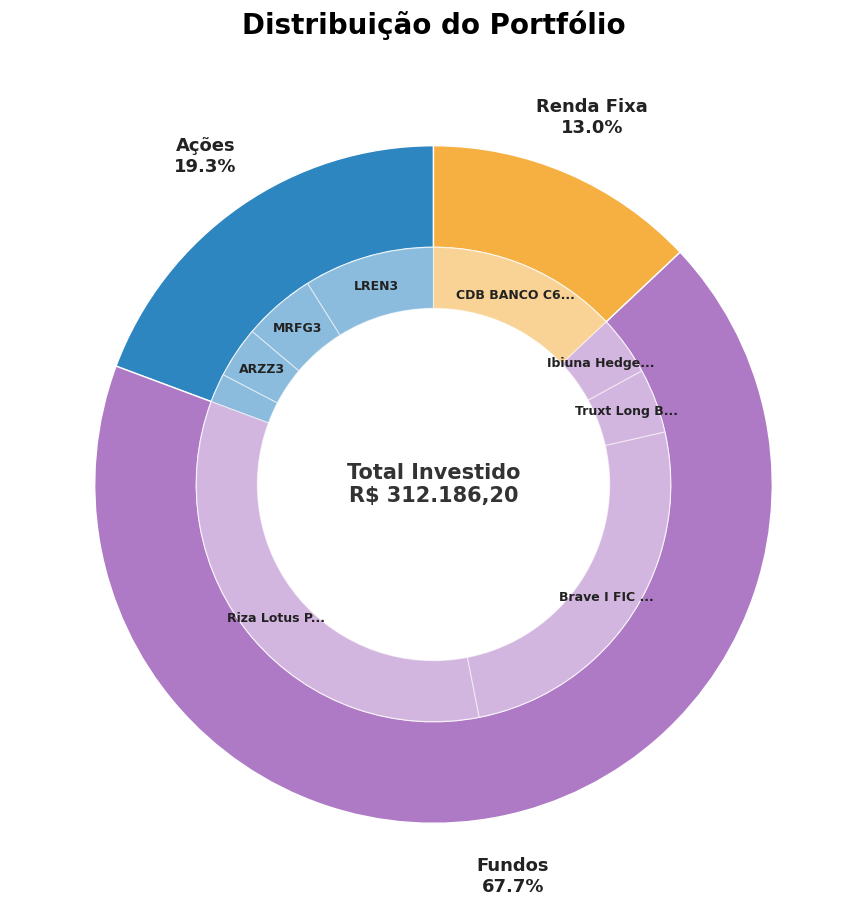

In [52]:
plot_portfolio_donut_with_inner_ring(resumo)

In [43]:
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import numpy as np

def plot_portfolio_donut_with_inner_ring(
    summary: PortfolioSummary,
    min_asset_pct_within_class=0.05,     # ativos menores que isso são omitidos
    min_label_angle_deg=8,               # ângulo mínimo para mostrar rótulo
    title="Distribuição do Portfólio"
):
    """
    Gera:
    - Aro principal (Ações, Fundos, Renda Fixa)
    - Anel interno com subfatias proporcionais
    - Rótulos internos (se houver espaço)
    - Valor total investido no centro
    - Porcentagem de cada classe na borda externa
    """

    # =============================
    # 1. Dados principais
    # =============================
    class_labels = ["Ações", "Fundos", "Renda Fixa"]
    raw_values = [
        summary.stocks_percentage,
        summary.funds_percentage,
        summary.fixed_income_percentage,
    ]

    # Conversão automática: valores entre 0–1 viram percentuais
    class_values = []
    class_pct_labels = []

    for v in raw_values:
        if v <= 1:          # assume proporção (0 a 1)
            pct = v * 100
        else:               # assume % direto (0 a 100)
            pct = v
        class_values.append(v)
        class_pct_labels.append(f"{pct:.1f}%")

    class_colors = {
        "Ações": "#2E86C1",
        "Fundos": "#AF7AC5",
        "Renda Fixa": "#F5B041",
    }

    outer_colors = [class_colors[c] for c in class_labels]

    # =============================
    # 2. Subfatias por classe
    # =============================
    def get_assets(items, class_pct):
        """Retorna lista de (nome, pct_normalizado)."""
        assets = []
        for item in items:
            if class_pct > 0:
                pct = item.allocation_percentage / class_pct
            else:
                pct = 0
            if pct >= min_asset_pct_within_class:
                name = getattr(item, "code", getattr(item, "name", "Ativo"))
                assets.append((name, pct))

        if not assets:
            return []

        total = sum(v for _, v in assets)
        return [(name, v / total) for name, v in assets]

    stocks = get_assets(summary.stocks, summary.stocks_percentage)
    funds = get_assets(summary.funds, summary.funds_percentage)
    fixed_income = get_assets(summary.fixed_income_securities, summary.fixed_income_percentage)

    inner_assets_list = [stocks, funds, fixed_income]

    # =============================
    # 3. Criar figura
    # =============================
    fig, ax = plt.subplots(figsize=(11, 11))
    ax.set_aspect("equal")

    # =============================
    # 4. Aro principal
    # =============================
    wedges, _ = ax.pie(
        class_values,
        labels=None,  # labels serão feitas manualmente para incluir %
        colors=outer_colors,
        radius=1.0,
        wedgeprops=dict(width=0.30, edgecolor="white"),
        startangle=90,
        labeldistance=None
    )

    # =============================
    # 4b. Adiciona rótulos externos (Classe + %)
    # =============================
    for w, label, pct in zip(wedges, class_labels, class_pct_labels):
        ang = np.deg2rad((w.theta1 + w.theta2) / 2)
        x = 1.18 * np.cos(ang)
        y = 1.18 * np.sin(ang)

        ax.text(
            x, y,
            f"{label}\n{pct}",
            ha="center", va="center",
            fontsize=13,
            fontweight="bold",
            color="#222"
        )

    # =============================
    # 5. Anel interno + rótulos
    # =============================
    for wedge, assets, class_name in zip(wedges, inner_assets_list, class_labels):

        if len(assets) == 0:
            continue

        theta1, theta2 = wedge.theta1, wedge.theta2
        total_angle = theta2 - theta1

        cumulative = np.cumsum([pct for _, pct in assets])
        inner_angles = [theta1] + list(theta1 + cumulative * total_angle)

        for (label, pct), a1, a2 in zip(assets, inner_angles[:-1], inner_angles[1:]):
            angle_span = a2 - a1

            # Subfatia
            inner_wedge = Wedge(
                center=(0, 0),
                r=0.70,
                width=0.18,
                theta1=a1,
                theta2=a2,
                facecolor=class_colors[class_name],
                edgecolor="white",
                linewidth=0.8,
                alpha=0.55,
            )
            ax.add_patch(inner_wedge)

            # Rótulo interno
            if angle_span >= min_label_angle_deg:
                mid_angle = np.deg2rad((a1 + a2) / 2)
                text_r = 0.61

                ax.text(
                    text_r * np.cos(mid_angle),
                    text_r * np.sin(mid_angle),
                    label,
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="#222",
                    fontweight="bold",
                    wrap=True
                )

    # =============================
    # 6. Valor investido no centro
    # =============================
    invested_text = f"Total Investido\nR$ {summary.total_invested:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

    ax.text(
        0, 0,
        invested_text,
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
        color="#333"
    )

    # =============================
    # 7. Título
    # =============================
    plt.title(title, fontsize=20, fontweight="bold", pad=20)

    plt.show()


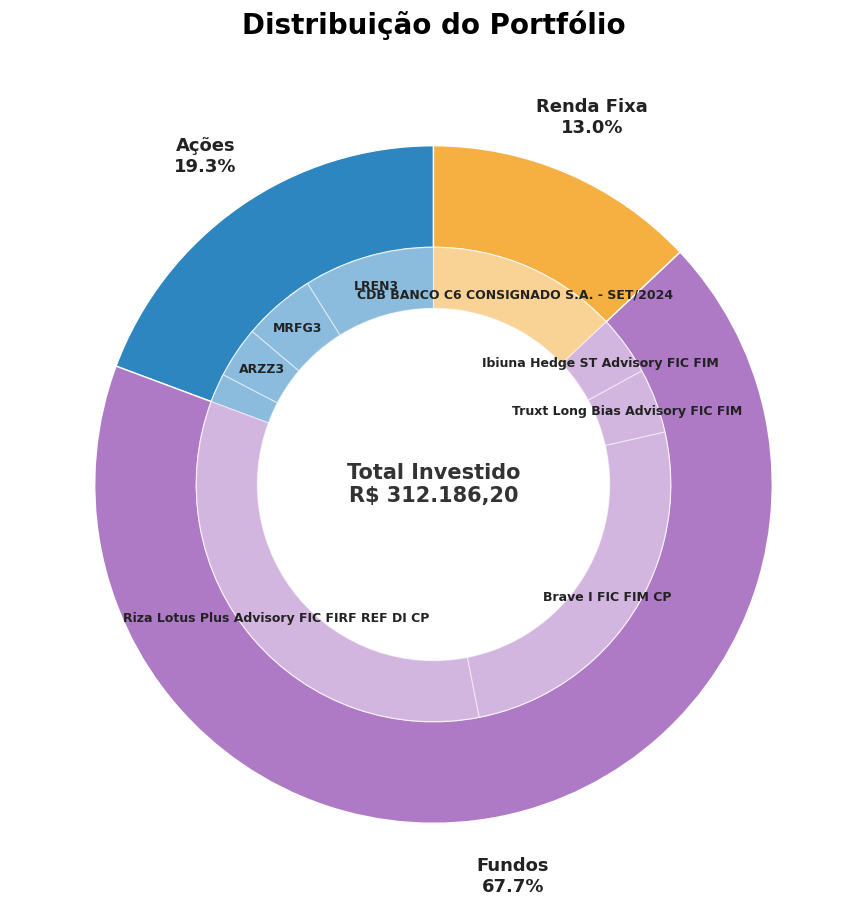

In [44]:
plot_portfolio_donut_with_inner_ring(resumo)

In [49]:
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
import numpy as np

def plot_portfolio_donut_with_inner_ring(
    summary: PortfolioSummary,
    min_asset_pct_within_class=0.03,     # ativos menores que isso são omitidos
    min_label_angle_deg=8,               # ângulo mínimo para mostrar rótulo
    title="Distribuição do Portfólio"
):
    """
    Cria um gráfico de rosca profissional com:
    - Aro principal (Ações, Fundos, Renda Fixa)
    - Anel interno proporcional aos ativos dentro da classe
    - Rótulos internos com ajuste automático de tamanho
    - Valor total investido no centro
    - Rótulos externos com porcentagem da classe
    """

    # =====================================================
    # 1. Dados principais (conversão automática de %)
    # =====================================================
    class_labels = ["Ações", "Fundos", "Renda Fixa"]
    raw_values = [
        summary.stocks_percentage,
        summary.funds_percentage,
        summary.fixed_income_percentage,
    ]

    class_values = []
    class_pct_labels = []

    for v in raw_values:
        if v <= 1:           # se veio como proporção (0–1)
            pct = v * 100
        else:                # se já veio em %
            pct = v
        class_values.append(v)
        class_pct_labels.append(f"{pct:.1f}%")

    class_colors = {
        "Ações": "#2E86C1",
        "Fundos": "#AF7AC5",
        "Renda Fixa": "#F5B041",
    }

    outer_colors = [class_colors[c] for c in class_labels]

    # =====================================================
    # 2. Processamento da composição dos ativos
    # =====================================================
    def get_assets(items, class_pct):
        """Retorna lista de (nome, pct_normalizado_dentro_da_classe)."""
        assets = []
        for item in items:
            pct = item.allocation_percentage / class_pct if class_pct > 0 else 0
            if pct >= min_asset_pct_within_class:
                name = getattr(item, "code", getattr(item, "name", "Ativo"))
                assets.append((name, pct))

        if not assets:
            return []

        total = sum(v for _, v in assets)
        return [(name, v / total) for name, v in assets]

    stocks = get_assets(summary.stocks, summary.stocks_percentage)
    funds = get_assets(summary.funds, summary.funds_percentage)
    fixed_income = get_assets(summary.fixed_income_securities, summary.fixed_income_percentage)

    inner_assets_list = [stocks, funds, fixed_income]

    # =====================================================
    # 3. Criar figura
    # =====================================================
    fig, ax = plt.subplots(figsize=(11, 11))
    ax.set_aspect("equal")

    # =====================================================
    # 4. Aro principal (classes)
    # =====================================================
    wedges, _ = ax.pie(
        class_values,
        labels=None,
        colors=outer_colors,
        radius=1.0,
        wedgeprops=dict(width=0.30, edgecolor="white"),
        startangle=90,
        labeldistance=None
    )

    # =====================================================
    # 4b. Adiciona rótulos externos: Classe + %
    # =====================================================
    for w, label, pct in zip(wedges, class_labels, class_pct_labels):
        ang = np.deg2rad((w.theta1 + w.theta2) / 2)
        x = 1.18 * np.cos(ang)
        y = 1.18 * np.sin(ang)

        ax.text(
            x, y,
            f"{label}\n{pct}",
            ha="center", va="center",
            fontsize=13,
            fontweight="bold",
            color="#222"
        )

    # =====================================================
    # 5. Anel fino interno (subfatias)
    # =====================================================
    renderer = fig.canvas.get_renderer()

    for wedge, assets, class_name in zip(wedges, inner_assets_list, class_labels):

        if len(assets) == 0:
            continue

        theta1, theta2 = wedge.theta1, wedge.theta2
        total_angle = theta2 - theta1

        cumulative = np.cumsum([pct for _, pct in assets])
        inner_angles = [theta1] + list(theta1 + cumulative * total_angle)

        for (label, pct), a1, a2 in zip(assets, inner_angles[:-1], inner_angles[1:]):
            angle_span = a2 - a1

            # Desenha subfatia
            inner_wedge = Wedge(
                center=(0, 0),
                r=0.70,
                width=0.18,
                theta1=a1,
                theta2=a2,
                facecolor=class_colors[class_name],
                edgecolor="white",
                linewidth=0.8,
                alpha=0.55,
            )
            ax.add_patch(inner_wedge)

            # Rótulo deve caber
            if angle_span >= min_label_angle_deg:
                mid_angle = np.deg2rad((a1 + a2) / 2)
                text_r = 0.61

                # ============================================
                # AUTO-SHRINK DO TEXTO — ajuste automático
                # ============================================
                for fs in [9, 8, 7, 6]:
                    text_obj = ax.text(
                        text_r * np.cos(mid_angle),
                        text_r * np.sin(mid_angle),
                        label,
                        ha="center", va="center",
                        fontsize=fs,
                        color="#222",
                        fontweight="bold",
                    )
                    bbox = text_obj.get_window_extent(renderer=renderer)

                    # espaço aproximado disponível na subfatia (px)
                    est_px = angle_span * (np.pi/180) * (0.70 * fig.dpi)

                    if bbox.width <= est_px:
                        break
                    else:
                        text_obj.remove()

    # =====================================================
    # 6. Valor investido no centro
    # =====================================================
    invested_text = f"Total Investido\nR$ {summary.total_invested:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

    ax.text(
        0, 0,
        invested_text,
        ha="center",
        va="center",
        fontsize=15,
        fontweight="bold",
        color="#333"
    )

    # =====================================================
    # 7. Título
    # =====================================================
    plt.title(title, fontsize=20, fontweight="bold", pad=20)

    plt.show()


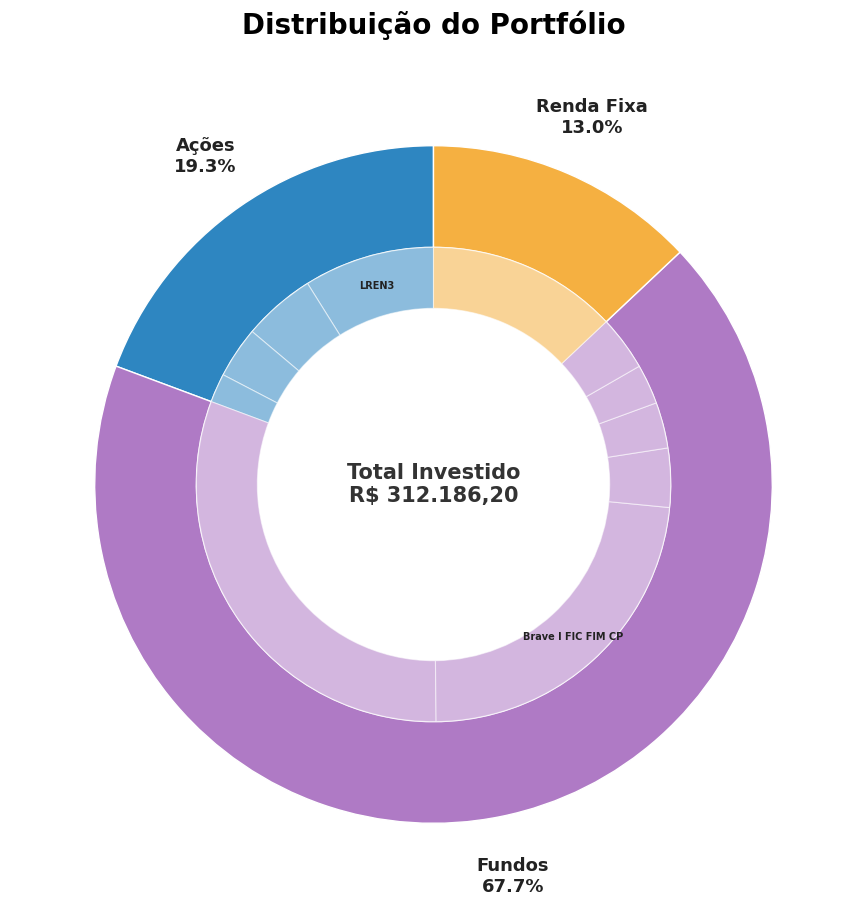

In [50]:
plot_portfolio_donut_with_inner_ring(resumo)

In [13]:
# Step 3: Gerar resumos
print("\n[2/4] Gerando resumos com IA...")

print("  → Gerando resumo do portfólio...")
portfolio_summary = summarize_portfolio_results(resumo_formatado)
print("  ✓ Resumo do portfólio gerado")



[2/4] Gerando resumos com IA...
  → Gerando resumo do portfólio...
  ✓ Resumo do portfólio gerado


In [14]:
print(portfolio_summary)

In October, Albert da Silva's portfolio totaled R$ 386,858.82, with an overall return reflecting mixed performance across asset classes. The portfolio's return was influenced significantly by the investment funds, which collectively achieved a positive return, notably the Riza Lotus Plus Advisory FIC FIRF REF DI CP and Brave I FIC FIM CP, with returns of 15.51% and 19.08%, respectively. Conversely, stocks underperformed, with LREN3 and HAPV3 experiencing substantial declines of -41.70% and -74.58%. The fixed income allocation, primarily in CDB BANCO C6, provided stability with a market rate of IPC-A +5.45%. 

Overall, the portfolio's performance highlights the importance of diversification, as strong gains in investment funds offset weaker stock performance. There were no significant changes in allocation or rebalancing mentioned this month, indicating a consistent investment strategy.


In [9]:
print(portfolio_summary)

In the latest performance review, the portfolio has achieved a total return of R$386,858.82, with a notable allocation of 67.71% in investment funds, which have delivered strong returns, particularly the Riza Lotus Plus Advisory FIC FIRF REF DI CP, yielding 15.51%. However, the equity segment, constituting 19.32% of the portfolio, has faced challenges, with significant losses from HAPV3 (-74.58%) and ARZZ3 (-31.05%), while MRFG3 provided a positive return of 43.5%. 

The fixed income allocation, at 12.97%, consists primarily of a CDB investment, which is performing steadily. Overall, the portfolio's performance reflects a mixed outcome, driven mainly by the strong performance of certain funds and the underwhelming results in equities. No rebalancing actions have been noted this month, indicating a stable investment strategy moving forward.


In [7]:
print("  → Gerando resumo do perfil de risco...")
risk_profile_summary = summarize_risk_profile(risk_profile_data)
print("  ✓ Resumo do perfil de risco gerado")

  → Gerando resumo do perfil de risco...
  ✓ Resumo do perfil de risco gerado


In [8]:
print(risk_profile_data)

Perfil de Risco do Cliente: Albert
Classificação do Perfil de Investimento: Moderado

1. Descrição do Perfil Moderado:
O perfil de investimento moderado posiciona o cliente em um ponto intermediário entre
conservador e arrojado. Isso significa que ele está disposto a assumir riscos moderados em
busca de retornos superiores aos investimentos totalmente conservadores, como investimento
em tesouro direto e instrumentos bancários como CDBs, mas ainda prefere uma certa
estabilidade e segurança.
O foco do investidor é preservar seu poder de compra e incrementá-lo marginalmente.
Albert está confortável em equilibrar suas aplicações entre investimentos seguros e outros com
um nível mais elevado de risco, buscando uma composição diversificada que ofereça boas
perspectivas de rendimento a médio e longo prazo. Ele aceita flutuações de mercado e
possíveis variações nos retornos de seus investimentos, visando um crescimento sustentável
de seu patrimônio no decorrer do tempo.

2. Produtos Financeiro

In [10]:
print("  → Gerando resumo macroeconômico...")
macro_outlook_summary = summarize_macroeconomic_outlook(macro_data)
print("  ✓ Resumo macroeconômico gerado")

  → Gerando resumo macroeconômico...
  ✓ Resumo macroeconômico gerado


In [12]:
print(macro_outlook_summary)

The macroeconomic outlook for Brazil indicates a complex landscape characterized by moderate growth, persistent inflation, and high interest rates. Despite a recent recovery in commodity prices and a temporary easing of global trade tensions, the Brazilian economy is showing signs of deceleration, with GDP growth projected at 2.0% for 2025, down from 3.6% in 2024. Inflation remains a pressing concern, with expectations for the IPCA to reach 6.1% this year before potentially easing to 4.5% in 2026, driven by a restrictive monetary policy. Investor sentiment reflects caution amid rising public debt and fiscal sustainability concerns, particularly as the government approaches electoral cycles. Analysts highlight the fragility of the recent appreciation of the Real, warning that renewed risk aversion could lead to further depreciation, complicating the balance between inflation control and economic growth. These factors necessitate careful consideration in investment strategies, particular

In [17]:
# Passo 3: Gerar carta de investimento
print("\n[3/4] Gerando carta de investimento...")

investment_letter = generate_investment_letter(
    risk_profile_summary,
    macro_outlook_summary,
    resumo_formatado
)
print("  ✓ Carta de investimento gerada")


[3/4] Gerando carta de investimento...
  ✓ Carta de investimento gerada


In [18]:
print(investment_letter)

Prezado Albert,

Espero que esteja bem. Segue o relatório de desempenho do seu portfólio referente ao mês. Agradecemos pela confiança depositada em nossos serviços e estamos aqui para auxiliá-lo na busca por um crescimento sustentável de seu patrimônio.

No que diz respeito aos resultados do seu portfólio, no total, seus ativos somam R$ 386.858,82, sendo que R$ 312.186,20 estão investidos. A alocação atual demonstra uma diversificação estratégica, com 19,32% em ações, 67,71% em fundos de investimento e 12,97% em renda fixa. Embora tenhamos observado algumas oscilações, especialmente nas ações, onde a Lojas Renner (LREN3) e a Hapvida (HAPV3) apresentaram desempenhos negativos, os fundos de investimento, como o Riza Lotus Plus e o Brave I, contribuíram positivamente com retornos de 15,51% e 19,08%, respectivamente. Essa diversificação reflete sua estratégia moderada, buscando um equilíbrio entre segurança e potencial de retorno.

Nesse contexto, o cenário macroeconômico brasileiro traz d

In [16]:
print(investment_letter)

Prezado Albert,

Espero que esta mensagem o encontre bem. Segue o relatório do mês de outubro, onde apresentamos uma análise detalhada do desempenho de sua carteira de investimentos, além de uma perspectiva macroeconômica que pode influenciar suas decisões futuras.

Em outubro, sua carteira totalizou R$ 386.858,82, refletindo um desempenho misto entre as classes de ativos. Os fundos de investimento foram os principais responsáveis pelo resultado positivo, destacando-se o Riza Lotus Plus Advisory FIC FIRF REF DI CP e o Brave I FIC FIM CP, com retornos de 15,51% e 19,08%, respectivamente. Por outro lado, as ações apresentaram um desempenho abaixo do esperado, com as ações LREN3 e HAPV3 registrando quedas significativas de -41,70% e -74,58%. A alocação em renda fixa, predominantemente em CDB BANCO C6, trouxe estabilidade, com uma taxa de mercado de IPC-A +5,45%. Esses resultados ressaltam a importância da diversificação, uma vez que os ganhos expressivos nos fundos compensaram o desempenh

In [5]:
# # Passo 4: Salvar resultado
# print("\n[4/4] Salvando resultado...")

# write_file(OUTPUT_FILE, investment_letter)
# print(f"  ✓ Carta salva em: {OUTPUT_FILE}")
# print(f"  ✗ Erro ao salvar arquivo: {str(e)}")

In [ ]:
# # Constrói uma lista de dicionários com as informações desejadas
# linhas = []

# for acao in resumo.stocks:
#     if acao.monthly_return is not None:
#         linhas.append({
#             "Código": acao.code,
#             "Quantidade": acao.quantity,
#             "Último Preço (R$)": acao.last_price,
#             "Preço Mês Anterior (R$)": acao.previous_month_price,
#             "Retorno Mensal (%)": acao.monthly_return
#         })
#     else:
#         linhas.append({
#             "Código": acao.code,
#             "Quantidade": acao.quantity,
#             "Último Preço (R$)": acao.last_price,
#             "Preço Mês Anterior (R$)": acao.previous_month_price,
#             "Retorno Mensal (%)": None
#         })

# # Cria o DataFrame
# df_retorno = pd.DataFrame(linhas)

# # Exibe a tabela
# print("\nRETORNO MENSAL DAS AÇÕES")
# print(df_retorno)


RETORNO MENSAL DAS AÇÕES
  Código  Quantidade  Último Preço (R$)  Preço Mês Anterior (R$)  \
0  LREN3        1642              13.88                14.500000   
1  MRFG3        1504              19.49                18.770000   
2  ARZZ3         193              25.67                27.334229   
3  HAPV3        1547              14.47                31.360001   

   Retorno Mensal (%)  
0           -4.275861  
1            3.835905  
2           -6.088441  
3          -53.858418  
